In [1]:
!git clone https://github.com/Arclight12/Hybrid_soc_Estimator.git
%cd Hybrid_soc_Estimator


Cloning into 'Hybrid_soc_Estimator'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 27 (delta 1), reused 23 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 54.44 KiB | 1.70 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/kaggle/working/Hybrid_soc_Estimator


In [2]:
!pip install -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 877.1/877.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 15.6 MB/s eta 0:00:00


In [3]:
!ls
!ls data_pipeline
!touch data_pipeline/__init__.py


config.py  data_pipeline  pyproject.toml  README.md  requirements.txt  uv.lock
build_dataset.py  generation  preprocessing  simulation


In [4]:
%cd /kaggle/working/Hybrid_soc_Estimator/Hybrid_soc_Estimator
!python -m data_pipeline.build_dataset --num-healthy 25 --num-degraded 25


[Errno 2] No such file or directory: '/kaggle/working/Hybrid_soc_Estimator/Hybrid_soc_Estimator'
/kaggle/working/Hybrid_soc_Estimator
At t = 255.299 and h = 6.74817e-10, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 255.299 and h = 6.74817e-10, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 321.963 repeated recoverable right-hand side function errors.
At t = 299.58 repeated recoverable right-hand side function errors.
At t = 538.014 repeated recoverable right-hand side function errors.
At t = 217.886 repeated recoverable right-hand side function errors.
At t = 217.886 repeated recoverable right-hand side function errors.
At t = 465.345 and h = 9.35809e-10, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 166.338 and h = 5.33655e-10, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 166.338 and h = 5.33655e-10, the corrector convergence test failed repeatedly or with |h| = hmi

In [5]:
import numpy as np

X_train = np.load("datasets/processed/X_train.npy")
y_train = np.load("datasets/processed/y_train.npy")
X_val   = np.load("datasets/processed/X_val.npy")
y_val   = np.load("datasets/processed/y_val.npy")
X_test  = np.load("datasets/processed/X_test.npy")
y_test  = np.load("datasets/processed/y_test.npy")

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# Inspect one sequence
print("First X sample:\n", X_train[0])   # 100 timesteps × 3 features
print("First y sample:", y_train[0])     # SOC target


Train: (374570, 100, 3) (374570,)
Val: (74914, 100, 3) (74914,)
Test: (85616, 100, 3) (85616,)
First X sample:
 [[-0.04001263 -0.02411157 -0.02312573]
 [-0.03999855 -0.02411157 -0.05220044]
 [-0.03998511 -0.02411157 -0.08010354]
 [-0.03997231 -0.02411157 -0.10688189]
 [-0.03996013 -0.02411157 -0.13257767]
 [-0.0399486  -0.02411157 -0.15723775]
 [-0.03993822 -0.02411157 -0.18090118]
 [-0.03992813 -0.02411157 -0.20360857]
 [-0.03991834 -0.02411157 -0.22539899]
 [-0.03990882 -0.02411157 -0.24630834]
 [-0.03989956 -0.02411157 -0.266371  ]
 [-0.03989054 -0.02411157 -0.28562292]
 [-0.03988174 -0.02411157 -0.30409378]
 [-0.03987314 -0.02411157 -0.3218179 ]
 [-0.03986474 -0.02411157 -0.33882347]
 [-0.03985652 -0.02411157 -0.35513854]
 [-0.03984847 -0.02411157 -0.3707913 ]
 [-0.03984058 -0.02411157 -0.38580978]
 [-0.03983285 -0.02411157 -0.40021747]
 [-0.03982527 -0.02411157 -0.41403934]
 [-0.03981782 -0.02411157 -0.42729884]
 [-0.03981051 -0.02411157 -0.44001943]
 [-0.03980333 -0.02411157 -0.4

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(100, 3)),
    layers.LSTM(128, return_sequences=True),   # first LSTM returns sequences
    layers.LSTM(64, return_sequences=False),   # second LSTM condenses sequence
    layers.Dense(32, activation="relu"),
    layers.Dense(1)   # SOC output
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()


2026-03-14 13:39:12.471369: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773495552.698669      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773495552.765732      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773495553.302582      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773495553.302610      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773495553.302613      24 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,105 (465.25 KB)

 Trainable params: 119,105 (465.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50


I0000 00:00:1773495582.668201     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


2927/2927 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 0.0232 - mae: 0.0838 - val_loss: 0.1066 - val_mae: 0.1624
Epoch 2/50
2927/2927 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 0.0126 - mae: 0.0623 - val_loss: 0.1448 - val_mae: 0.1827
Epoch 3/50
2927/2927 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 0.0078 - mae: 0.0486 - val_loss: 0.0217 - val_mae: 0.1089
Epoch 4/50
2927/2927 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 0.0070 - mae: 0.0456 - val_loss: 0.0248 - val_mae: 0.0953
Epoch 5/50
2927/2927 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 0.0069 - mae: 0.0439 - val_loss: 0.0586 - val_mae: 0.1276
Epoch 6/50
2927/2927 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 0.0086 - mae: 0.0483 - val_loss: 0.1108 - val_mae: 0.1581
Epoch 7/50
2927/2927 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 0.0060 - mae: 0.0408 - val_loss: 0.1500 - val_mae: 0.1791
Epoch 8/50
2927/2927 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 0.0060 - mae: 0.0376 - val_loss: 0.1208 - val_mae: 0.1693


In [8]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")


2676/2676 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.2810 - mae: 0.4457
Test Loss: 0.1345, Test MAE: 0.2441


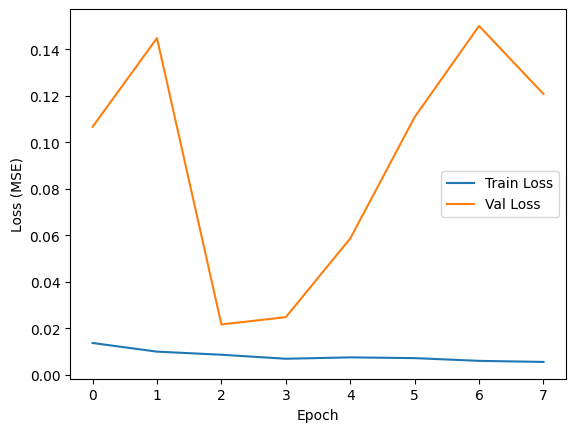

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()


In [10]:
model.save("soc_lstm_model.h5")
